## Inclusions and imports

In [2]:
using Shapefile, Plots, DataFrames, Rasters, ArchGDAL, LsqFit, SymbolicRegression
using Serialization, Statistics
using Proj: CRS


In [3]:
include("src/src.jl")

source included!

## Verify files and genetare raw map tif

In [ ]:
get_sample_dimensions("data/21S42_ZN.tif")

In [ ]:
gen_main_matrix()

In [ ]:
h_show("data/sample_map/concat_rio.tif", 12)

## Applying the masks to isolate the state

In [ ]:
# 1. Load one of your TOPODATA tiles to use as a template
tile_path = "data/sample_map/concat_rio.tif" 
elevation = Raster(tile_path)

# 2. Create the mask for this specific tile's area
rj_mask = create_state_mask(elevation, "data/border_info/lml_unidade_federacao_a.shp")

# 3. Apply the 3000 value to outside areas
masked_elevation_land = apply_flood_boundary!(elevation, rj_mask, 3000)

# 4. Save the result
write("processed_masked.tif", masked_elevation_land, force=true)

In [ ]:
h_show("processed_masked.tif", 3)

In [ ]:
# 1. Load one of your TOPODATA tiles to use as a template
tile_path = "data/sample_map/concat_rio.tif" 
elevation = Raster(tile_path)

# 2. Create the mask for this specific tile's area
land_mask = create_states_mask(elevation, "data/border_info/lml_unidade_federacao_a.shp", ("RJ", "SP", "ES", "MG"))

# 3. Apply the 3000 value to outside areas
masked_elevation_water = apply_flood_boundary!(elevation, land_mask, -10)

# 4. Save the result
write("data/water_mask.tif", masked_elevation_water, force=true)

In [ ]:
h_show("data/water_mask.tif", 3)

In [ ]:
tile_path = "data/sample_map/concat_rio.tif" 
elevation = Raster(tile_path)

rj_mask = create_state_mask(elevation, "data/border_info/lml_unidade_federacao_a.shp")
land_mask = create_states_mask(elevation, "data/border_info/lml_unidade_federacao_a.shp", ("RJ", "SP", "ES", "MG"))

masked_elevation_complete = apply_flood_boundary!(elevation, rj_mask, 3000)
masked_elevation_complete = apply_flood_boundary!(elevation, land_mask, -10)

write("complete_map.tif", masked_elevation_complete, force=true)

In [ ]:
h_show("complete_map.tif", 3)

## Creating a visual representation of the flood

In [34]:
flood_map = Raster("data/complete_map.tif")
rows, cols = size(flood_map)
water_level = -1
step = 50
flood_mask = create_flood_mask(rows, cols)

flood_counter = expand_flood_best!(flood_map, flood_mask, water_level)
flooded_area = (flood_counter*900)*10^(-6)

println("Flooded area: $(flooded_area)km²")

earth_small = flood_map[1:step:end, 1:step:end]
water_small = flood_mask[1:step:end, 1:step:end]
println("Downsampled grid size: $(size(earth_small))")
flood_map = nothing
flood_mask = nothing
GC.gc()

save_flood_snapshot(earth_small, water_small, "visualization/flood_direct_render$(water_level).png")

Flooded area: 0.0km²
Downsampled grid size: (324, 216)
Generating raw image...
Writing to disk: visualization/flood_direct_render-1.png
Saved!


### Iterate flooding by water level (step 1)

DO NOT RUN THIS CELL IF THE `"data/flood_data_complete.jls"` IS ALREADY CREATED (it will take a while to iterate through it all lol)

In [ ]:
flood_map = Raster("complete_map.tif")
rows, cols = size(flood_map)
water_layer = create_flood_mask(rows, cols)

level_x_area = Tuple[]

for level in 1:1:1500
    print("$(E)Iterating through water_level: $(level)")
    flood_mask = copy(water_layer)
    flood_counter = expand_flood_best!(flood_map, flood_mask, level)
    flooded_area = (flood_counter*900)*10^(-6)

    push!(level_x_area, (level, flooded_area))
end

println("\nArray complete")

LoadError: ArgumentError: file "complete_map.tif" not found

In [ ]:
level_x_area

In [ ]:
serialize("flood_data_complete.jls",level_x_area)

In [8]:
curve_data = deserialize("data/flood_data_complete.jls")

x_vals = [x[1] for x in curve_data] # Water Levels
y_vals = [x[2] for x in curve_data] # Flooded Area (pixels)
y_vals .*=100/43750


p = plot(x_vals, y_vals, 
     title="Hypsometric Curve (Rio Flood)",
     xlabel="Water Level (m)",
     ylabel="Flooded Area (%)",
     legend=false,
     linewidth=2)
    
savefig(p, "true_curve.png")

"/home/oliver/Code/sidestuff/Julia_exploration/true_curve.png"

## Calculating the water level x flooded area curve

### First approach (LsqFit.jl)

In [9]:
println("\n--- Running Approach A: Power Law Fit ---")

# Model: A = a * h^b + c
@. model_power(x, p) = p[1] * (x ^ p[2]) + p[3]
p0 = [100.0, 2.0, 0.0] # Initial guess

fit_power = curve_fit(model_power, x_data, y_data, p0)
params_power = fit_power.param

# Calculate RMSE for comparison
y_pred_power = model_power(x_data, params_power)
rmse_power = sqrt(mean((y_data .- y_pred_power).^2))

println("Power Law Formula: Area = $(round(params_power[1], digits=2)) * h ^ $(round(params_power[2], digits=2)) + $(round(params_power[3], digits=2))")
println("Power Law RMSE: $(round(rmse_power, digits=2))")


--- Running Approach A: Power Law Fit ---


LoadError: UndefVarError: `x_data` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

### Second approach (SymbolicRegression.jl)

In [6]:
X_matrix = reshape(x_data, (1, length(x_data)))

options = Options(
    binary_operators=[+, *, /, -],
    unary_operators=[exp, log, sqrt], # Add specific operators if needed
    npopulations=20,
    parsimony=0.0001 # Penalty for complexity (prevents overfitting)
)

# Run the genetic algorithm
hall_of_fame = EquationSearch(
    X_matrix, y_data, 
    niterations=30, # Increase this for better results (e.g., 100)
    options=options,
    parallelism=:multithreading
)

# Get the dominating equations (Pareto Frontier)
dominating = calculate_pareto_frontier(X_matrix, y_data, hall_of_fame, options)

println("\nTop 3 AI Equations:")

# We will pick the best one automatically based on a score
# (Score = roughly accuracy / complexity)
best_ai_idx = argmin([member.loss for member in dominating])
best_member = dominating[best_ai_idx]

for (i, member) in enumerate(dominating)
    # USER REQUEST: Using compute_complexity instead of .complexity
    comp = compute_complexity(member.tree, options)
    
    # Only print the best few or the final chosen one
    if i >= length(dominating) - 3
        println("Complexity $comp: $(string_tree(member.tree, options))")
        println("Loss: $(member.loss)")
    end
end

# Generate predictions for the best AI model
# eval_tree_array returns predictions for the input matrix X
y_pred_ai = eval_tree_array(best_member.tree, X_matrix, options)[1]
rmse_ai = sqrt(mean((y_data .- y_pred_ai).^2))

println("\nChosen AI RMSE: $(round(rmse_ai, digits=2))")

LoadError: UndefVarError: `x_data` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

### Visual comparison


--- Generating Plot ---


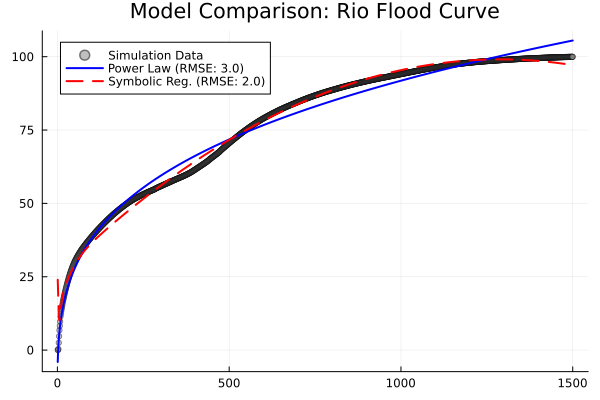

Saved comparison plot to 'model_comparison.png'


In [52]:
println("\n--- Generating Plot ---")

p = scatter(x_data, y_data, 
    label="Simulation Data", 
    color=:gray, 
    alpha=0.5, 
    markersize=3,
    legend=:topleft,
    title="Model Comparison: Rio Flood Curve")

# Plot Power Law
plot!(p, x_data, y_pred_power, 
    label="Power Law (RMSE: $(round(rmse_power, digits=0)))", 
    linewidth=2, 
    color=:blue)

# Plot AI Model
plot!(p, x_data, y_pred_ai, 
    label="Symbolic Reg. (RMSE: $(round(rmse_ai, digits=0)))", 
    linewidth=2, 
    linestyle=:dash, 
    color=:red)

display(p)
savefig("model_comparison_percentual.png")
println("Saved comparison plot to 'model_comparison.png'")

In [42]:
f(x) =((log(x + (141.70027907268204 - sqrt((0.9679165094591683 * x) / exp(6.293955826016116 / x)))) * 11.829888922571685) + -50.64212528363117) * (2.8710935889931384 / exp(6.293955826016116 / x))

f (generic function with 1 method)

### Third approach (raw data + extended max height)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
Evolving for 30 iterations... 100%|██████████████████████| Time: 0:00:51


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.461e+07  3.604e+01  y = 38534
3           6.424e+07  7.483e-02  y = x₁ + 37134
4           4.585e+07  3.373e-01  y = sqrt(x₁ * 1.0808e+06)
5           2.810e+07  4.895e-01  y = (x₁ * 8.4373) + 26718
6           5.477e+06  1.635e+00  y = (log(x₁) + -2.3365) * 8372.2
8           5.062e+06  3.945e-02  y = (log(x₁ + 9.0844) + -2.6057) * 8848.7
9           4.782e+06  5.694e-02  y = 15908 - ((-31.585 - (x₁ * -0.008264)) * x₁)
10          2.827e+06  5.257e-01  y = 13294 - (((sqrt(x₁) * 0.79198) + -51.551) * x₁)
12          1.705e+06  2.528e-01  y = 40593 - ((x₁ - 1041.1) * ((sqrt(x₁) * 0.59069) + -31.1...
                                      88))
14          5.808e+05  5.384e-01  y = 9869.7 - (x₁ * ((x₁ * ((sqrt(x₁) * -0.00055924) + 0.04...
                                      6703)) + -60.302))
16          5.808e+05  2.194e-07  y = 986

[ Info: Final population:
[ Info: Results saved to:


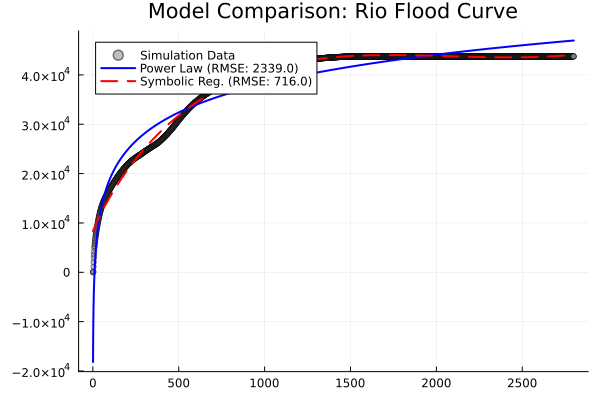

Saved comparison plot to 'model_comparison.png'


In [ ]:
# ==========================================
# 1. SETUP & DATA PREPARATION
# ==========================================
curve_data = deserialize("data/flood_data_complete.jls")

if size(curve_data)[1] <= 1500
    for i in 1501:1:2800
    push!(curve_data,(i,43750.50))
    end
end

x_data = Float64.([d[1] for d in curve_data]) # Water Level (m)
y_data = Float64.([d[2] for d in curve_data]) # Flooded Area (pixels)

# We need a matrix for SymbolicRegression (1 row, N columns)
X_matrix = reshape(x_data, (1, length(x_data)))

println("Data loaded: $(length(x_data)) points.")

# ==========================================
# 2. APPROACH A: The "Physicist" (Power Law)
# ==========================================
println("\n--- Running Approach A: Power Law Fit ---")

# Model: A = a * h^b + c
@. model_power(x, p) = p[1] * (x ^ p[2]) + p[3]
p0 = [100.0, 2.0, 0.0] # Initial guess

fit_power = curve_fit(model_power, x_data, y_data, p0)
params_power = fit_power.param

# Calculate RMSE for comparison
y_pred_power = model_power(x_data, params_power)
rmse_power = sqrt(mean((y_data .- y_pred_power).^2))

println("Power Law Formula: Area = $(round(params_power[1], digits=2)) * h ^ $(round(params_power[2], digits=2)) + $(round(params_power[3], digits=2))")
println("Power Law RMSE: $(round(rmse_power, digits=2))")

# ==========================================
# 3. APPROACH B: The "AI" (Symbolic Regression)
# ==========================================
println("\n--- Running Approach B: Symbolic Regression ---")

options = Options(
    binary_operators=[+, *, /, -],
    unary_operators=[exp, log, sqrt], # Add specific operators if needed
    npopulations=20,
    parsimony=0.0001 # Penalty for complexity (prevents overfitting)
)

# Run the genetic algorithm
hall_of_fame = EquationSearch(
    X_matrix, y_data, 
    niterations=30, # Increase this for better results (e.g., 100)
    options=options,
    parallelism=:multithreading
)

# Get the dominating equations (Pareto Frontier)
dominating = calculate_pareto_frontier(X_matrix, y_data, hall_of_fame, options)

println("\nTop 3 AI Equations:")

# We will pick the best one automatically based on a score
# (Score = roughly accuracy / complexity)
best_ai_idx = argmin([member.loss for member in dominating])
best_member = dominating[best_ai_idx]

for (i, member) in enumerate(dominating)
    # USER REQUEST: Using compute_complexity instead of .complexity
    comp = compute_complexity(member.tree, options)
    
    # Only print the best few or the final chosen one
    if i >= length(dominating) - 3
        println("Complexity $comp: $(string_tree(member.tree, options))")
        println("Loss: $(member.loss)")
    end
end

# Generate predictions for the best AI model
# eval_tree_array returns predictions for the input matrix X
y_pred_ai = eval_tree_array(best_member.tree, X_matrix, options)[1]
rmse_ai = sqrt(mean((y_data .- y_pred_ai).^2))

println("\nChosen AI RMSE: $(round(rmse_ai, digits=2))")

# ==========================================
# 4. VISUAL COMPARISON
# ==========================================
println("\n--- Generating Plot ---")

p = scatter(x_data, y_data, 
    label="Simulation Data", 
    color=:gray, 
    alpha=0.5, 
    markersize=3,
    legend=:topleft,
    title="Model Comparison: Rio Flood Curve")

# Plot Power Law
plot!(p, x_data, y_pred_power, 
    label="Power Law (RMSE: $(round(rmse_power, digits=0)))", 
    linewidth=2, 
    color=:blue)

# Plot AI Model
plot!(p, x_data, y_pred_ai, 
    label="Symbolic Reg. (RMSE: $(round(rmse_ai, digits=0)))", 
    linewidth=2, 
    linestyle=:dash, 
    color=:red)

display(p)
savefig("model_comparison_raw.png")
println("Saved comparison plot to 'model_comparison.png'")

In [22]:
hall_of_fame

HallOfFame{...}:
    .exists[1] = true
    .members[1] = PopMember(tree = (38534.377623650435), loss = 7.461150137036552e7, cost = 0.047942920429231074)
    .exists[2] = true
    .members[2] = PopMember(tree = (sqrt(1.0808017821356768e6)), loss = 1.480468637792299e9, cost = 0.9495166862792095)
    .exists[3] = true
    .members[3] = PopMember(tree = (x1 + 37133.87758531287), loss = 6.424013008552031e7, cost = 0.04149251555926579)
    .exists[4] = true
    .members[4] = PopMember(tree = (sqrt(x1 * 1.0808017821356768e6)), loss = 4.584686271527033e7, cost = 0.02979825313647478)
    .exists[5] = true
    .members[5] = PopMember(tree = ((x1 * 8.43727495493658) + 26717.97404924557), loss = 2.8102269641903598e7, cost = 0.01851993825569044)
    .exists[6] = true
    .members[6] = PopMember(tree = ((log(x1) + -2.336456872857871) * 8372.191088611295), loss = 5.47741014992877e6, cost = 0.004112264073841285)
    .exists[7] = true
    .members[7] = PopMember(tree = ((5185.828239807324 * log(x1)) + 

## Special Requirements

### Inverted curve

In [33]:
curve_data = deserialize("data/flood_data_complete.jls")

if size(curve_data)[1] <= 1500
    for i in 1501:1:2800
    push!(curve_data,(i,43750.50))
    end
end

y_vals = [x[1] for x in curve_data] # Water Levels
x_vals = [x[2] for x in curve_data] # Flooded Area (pixels)
x_vals .*=100/43750



p = plot(x_vals, y_vals, 
     title="Hypsometric Curve (Rio Flood)",
     ylabel="Water Level (m)",
     xlabel="Flooded Area (%)",
     legend=false,
     linewidth=2)
    
savefig(p, "report_assets/inverted_curve.png")

"/home/oliver/Code/sidestuff/Julia_exploration/report_assets/inverted_curve.png"

### 50 meter flood %

In [ ]:
println(curve_data[50])
println("$(curve_data[50][2]*100/43750.50)%")


(50, 13156.6464)
70.54824562005004%
